In [1]:
import sys
sys.path.insert(0, '/mnt/home/mlee1/vdm_BIND')

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from bind.config_loader import ConfigLoader
from bind.model_manager import ModelManager
from vdm.astro_dataset import get_astro_data


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

/mnt/sw/nix/store/gpkc8q6zjnp3n3h3w9hbmbj6gjbxs85w-python-3.10.10-view/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/mnt/sw/nix/store/6qvrglgqdpwhbw9zv2nh07fpd7a4wq31-py-torchvision-0.15.2/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Using device: cuda


## 1. Load Model from Config

In [2]:
# Choose your config file
CONFIG_PATH = '/mnt/home/mlee1/vdm_BIND/configs/clean_vdm_gas_and_star.ini'

# Load config and model
config = ConfigLoader(CONFIG_PATH, verbose=True)
print(f"\nBest checkpoint: {config.best_ckpt}")
print(f"Include halo mass: {getattr(config, 'include_halo_mass', False)}")
print(f"Param prediction weight: {getattr(config, 'param_prediction_weight', 0.0)}")

[ConfigLoader] Converted legacy_fourier=False to fourier_legacy
[ConfigLoader] conditioning_channels not in config or None, using default: 1
[ConfigLoader] 🌟 Quantile normalization enabled: /mnt/home/mlee1/vdm_BIND/data/quantile_normalizer_stellar.pkl
[ConfigLoader] Loaded config from: /mnt/home/mlee1/vdm_BIND/configs/clean_vdm_gas_and_star.ini
[ConfigLoader] Parameters:
  seed: 8
  dataset: IllustrisTNG
  data_root: /mnt/home/mlee1/ceph/train_data_rotated2_128_cpu/train/
  field: gas
  boxsize: 6.25
  batch_size: 128
  num_workers: 40
  cropsize: 128
  max_epochs: 250
  learning_rate: 5e-05
  lr_scheduler: cosine_warmup
  weight_decay: 0.0001
  noise_schedule: learned_nn
  gamma_min: -13.3
  gamma_max: 13.0
  data_noise: (0.001, 0.001, 0.001)
  antithetic_time_sampling: True
  n_blocks: 5
  embedding_dim: 96
  norm_groups: 8
  n_attention_heads: 8
  large_scale_channels: 3
  dropout: 0.1
  use_cross_attention: False
  add_attention: True
  use_fourier_features: True
  legacy_fourier: 

2025-12-21 17:52:20.910194: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-21 17:52:20.949820: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F AVX512_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.


[ConfigLoader] Found val/elbo: best=3.7015 at step 8306
[ConfigLoader] Best validation at step 8306
[ConfigLoader] TensorBoard log path: /mnt/home/mlee1/ceph/tb_logs3/clean_vdm_gas_and_star/version_0/
[ConfigLoader] Found checkpoint: /mnt/home/mlee1/ceph/tb_logs3/clean_vdm_gas_and_star/version_0//checkpoints/epoch=11-step=7668-val_elbo=0.0000.ckpt

Best checkpoint: /mnt/home/mlee1/ceph/tb_logs3/clean_vdm_gas_and_star/version_0//checkpoints/epoch=11-step=7668-val_elbo=0.0000.ckpt
Include halo mass: False
Param prediction weight: 0.1


In [3]:
# Initialize model
_, model = ModelManager.initialize(config, verbose=True, skip_data_loading=True)
model = model.to(DEVICE).eval()

# Get the score model (UNet)
score_model = model.model
print(f"\nScore model type: {type(score_model).__name__}")
print(f"Has param_prediction_head: {hasattr(score_model, 'param_prediction_head')}")

[ModelManager] Defaulting to 'clean' model type
[ModelManager] Initializing CLEAN model (single 3-channel model)...
[ModelManager] Using seed: 8
[ModelManager] Dataset: IllustrisTNG
[ModelManager] Data root: /mnt/home/mlee1/ceph/train_data_rotated2_128_cpu/train/
[ModelManager] Batch size: 128
[ModelManager] ⚠️  Skipping data loading (using pre-loaded samples)
[ModelManager] BEFORE auto-detect: conditioning_channels = 1
[ModelManager] BEFORE auto-detect: large_scale_channels = 3
[ModelManager] BEFORE auto-detect: use_fourier_features = True
[ModelManager] BEFORE auto-detect: fourier_legacy = False
[ModelManager] Checkpoint path: /mnt/home/mlee1/ceph/tb_logs3/clean_vdm_gas_and_star/version_0//checkpoints/epoch=11-step=7668-val_elbo=0.0000.ckpt


Seed set to 8


[ModelManager] Using fourier_legacy=False from config file (not auto-detecting)
[ModelManager] New multi-scale Fourier mode channel breakdown:
  Total conv_in: 39
  = input(3) + conditioning(1) + fourier_halo(8) + large_scale(3) + fourier_largescale(24)
[ModelManager] Final channel configuration:
  conditioning_channels: 1
  large_scale_channels: 3
  fourier_legacy: False
[ModelManager] Setting up parameter conditioning...
[ModelManager] Loaded 35 param bounds from /mnt/home/mlee1/Sims/IllustrisTNG_extras/L50n512/SB35/SB35_param_minmax.csv
[ModelManager] Skipping dataset loading (inference-only mode)
[ModelManager] Creating UNetVDM model...
[ModelManager] Model configuration:
  - use_fourier_features: True
  - fourier_legacy: False
  - conditioning_channels: 1
  - large_scale_channels: 3
  - use_cross_attention: False
✓ Scale-appropriate Fourier features enabled:
  - Halo (m_dm): High frequencies [1, 2, 4, 8]π -> 8 features per channel
  - Large-scale: Low frequencies [0.25, 0.5, 1, 2]

## 2. Load Test Data

In [4]:
# Load test data
test_root = '/mnt/home/mlee1/ceph/train_data_rotated2_128_cpu/test/'
include_halo_mass = getattr(config, 'include_halo_mass', False)

datamodule = get_astro_data(
    'IllustrisTNG', 
    test_root, 
    batch_size=8, 
    num_workers=4, 
    stage='test',
    quantile_path='/mnt/home/mlee1/vdm_BIND/data/quantile_normalizer_stellar.pkl',
    include_halo_mass=include_halo_mass,
)
datamodule.setup(stage='test')

# Get a batch
test_batch = next(iter(datamodule.test_dataloader()))
conditions, large_scale_maps, targets, params = test_batch

print(f"Condition shape: {conditions.shape}")
print(f"Large-scale shape: {large_scale_maps.shape}")
print(f"Target shape: {targets.shape}")
print(f"Params shape: {params.shape}")

✓ Loaded DM stats: mean=9.915499, std=0.467967
✓ Loaded Gas stats: mean=9.177344, std=0.410510
✓ Loading quantile transformer from: /mnt/home/mlee1/vdm_BIND/data/quantile_normalizer_stellar.pkl
  Quantile transformer loaded (n_quantiles=10000)
  Output distribution: uniform

📊 NORMALIZATION CONFIG (3-channel mode):
  DM input: mean=9.9777, std=0.4139
  DM target: mean=9.9155, std=0.4680
  Gas target: mean=9.1773, std=0.4105
  Stars target: QUANTILE TRANSFORMATION (n_quantiles=10000)
✓ Loaded DM stats: mean=9.915499, std=0.467967
✓ Loaded Gas stats: mean=9.177344, std=0.410510
✓ Loading quantile transformer from: /mnt/home/mlee1/vdm_BIND/data/quantile_normalizer_stellar.pkl
  Quantile transformer loaded (n_quantiles=10000)
  Output distribution: uniform

📊 NORMALIZATION CONFIG (3-channel mode):
  DM input: mean=9.9777, std=0.4139
  DM target: mean=9.9155, std=0.4680
  Gas target: mean=9.1773, std=0.4105
  Stars target: QUANTILE TRANSFORMATION (n_quantiles=10000)
📂 Loading file list from

/mnt/home/mlee1/venvs/torch3/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator QuantileTransformer from version 1.2.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Condition shape: torch.Size([1, 1, 128, 128])
Large-scale shape: torch.Size([1, 3, 128, 128])
Target shape: torch.Size([1, 3, 128, 128])
Params shape: torch.Size([1, 35])


## 3. Test Parameter Prediction

The auxiliary task predicts parameters from the bottleneck features. Let's see if it can recover the input parameters.

In [5]:
# Move data to device
cond = conditions.to(DEVICE)
large_scale = large_scale_maps.to(DEVICE)
target = targets.to(DEVICE)
param = params.to(DEVICE)

# Create full conditioning (DM + large-scale)
full_cond = torch.cat([cond, large_scale], dim=1)
print(f"Full conditioning shape: {full_cond.shape}")

# Model structure: LightCleanVDM.model -> CleanVDM
# CleanVDM contains score_model (UNetVDM) which has the param_predictor
clean_vdm = model.model  # CleanVDM
unet = clean_vdm.score_model  # UNetVDM

print(f"CleanVDM type: {type(clean_vdm).__name__}")
print(f"UNet type: {type(unet).__name__}")
print(f"Use param prediction: {clean_vdm.use_param_prediction}")

# Get n_params from the parameter embedding
n_params = unet.param_conditioning_embedding.Nparams
print(f"Model expects {n_params} parameters")

# Handle halo mass slicing if needed
if param.shape[1] > n_params:
    param_input = param[:, :n_params]
    print(f"Sliced params from {param.shape[1]} to {n_params}")
else:
    param_input = param

print(f"Input params shape: {param_input.shape}")

# Get normalization bounds from the embedding
param_min = unet.param_conditioning_embedding.min
param_max = unet.param_conditioning_embedding.max
print(f"\nParameter normalization:")
print(f"  Min: {param_min[:5].tolist()}... (first 5)")
print(f"  Max: {param_max[:5].tolist()}... (first 5)")

Full conditioning shape: torch.Size([1, 4, 128, 128])
CleanVDM type: CleanVDM
UNet type: UNetVDM
Use param prediction: True
Model expects 35 parameters
Input params shape: torch.Size([1, 35])

Parameter normalization:
  Min: [0.10000000149011612, 0.6000000238418579, 0.8999999761581421, 0.25, 3.700000047683716]... (first 5)
  Max: [0.5, 1.0, 14.399999618530273, 4.0, 14.800000190734863]... (first 5)


In [6]:
# Run forward pass to get parameter predictions
# We use CleanVDM's score_model call which properly interfaces with UNet

with torch.no_grad():
    # Sample a diffusion timestep
    t = torch.ones(cond.shape[0], device=DEVICE) * 0.5  # midpoint
    
    # Get gamma from CleanVDM's noise schedule
    gamma_t = clean_vdm.gamma(t)
    alpha_t = torch.sqrt(torch.sigmoid(-gamma_t))[:, None, None, None]
    sigma_t = torch.sqrt(torch.sigmoid(gamma_t))[:, None, None, None]
    
    # Create noisy input
    noise = torch.randn_like(target)
    z_t = alpha_t * target + sigma_t * noise
    
    # Forward pass through CleanVDM.score_model (UNet wrapper)
    # This properly calls UNet with: z_t, gamma_t, conditioning, params
    result = clean_vdm.score_model(
        z_t, 
        g_t=gamma_t, 
        conditioning=full_cond, 
        param_conditioning=param_input
    )
    
    # Unpack - returns tuple if param prediction enabled
    if isinstance(result, tuple):
        output = result[0]
        param_pred_normalized = result[1] if len(result) > 1 else None
    else:
        output = result
        param_pred_normalized = None
    
print(f"Output shape: {output.shape}")
print(f"Predicted params shape: {param_pred_normalized.shape if param_pred_normalized is not None else 'None'}")
print(f"Has param predictor: {unet.param_predictor is not None}")

Output shape: torch.Size([1, 3, 128, 128])
Predicted params shape: torch.Size([1, 35])
Has param predictor: True


In [7]:
# Load parameter names from CSV
import pandas as pd
param_df = pd.read_csv('/mnt/home/mlee1/50Mpc_boxes/data/param_df.csv')
param_names = list(param_df.columns)
print(f"Loaded {len(param_names)} parameter names from CSV")
print(f"First 10 param names: {param_names[:10]}")

# Create name mapping for common cosmological parameters
# CSV uses different naming conventions
PARAM_DISPLAY_NAMES = {
    'Omega0': 'Omega_m',
    'OmegaBaryon': 'Omega_b', 
    'HubbleParam': 'h',
    'n_s': 'n_s',
    'sigma8': 'sigma_8',
    'WindEnergyIn1e51erg': 'A_SN1',
    'BlackHoleFeedbackFactor': 'A_AGN1',
}

def get_param_index(name):
    """Get parameter index, handling name aliases."""
    if name in param_names:
        return param_names.index(name)
    # Try reverse lookup
    for csv_name, display_name in PARAM_DISPLAY_NAMES.items():
        if name == display_name and csv_name in param_names:
            return param_names.index(csv_name)
    return None

# Compare predicted vs actual parameters
# IMPORTANT: UNet predicts NORMALIZED params [0,1], we need to denormalize or normalize true params

if param_pred_normalized is not None:
    # Get normalization bounds
    param_min_dev = param_min.to(DEVICE)
    param_max_dev = param_max.to(DEVICE)
    
    # Option 1: Denormalize predictions to original scale
    param_pred_denorm = param_pred_normalized * (param_max_dev - param_min_dev) + param_min_dev
    param_pred_np = param_pred_denorm.cpu().numpy()
    param_true_np = param_input.cpu().numpy()
    
    # Option 2: Normalize true params for comparison
    param_true_normalized = (param_input - param_min_dev) / (param_max_dev - param_min_dev + 1e-8)
    param_true_normalized = torch.clamp(param_true_normalized, 0.0, 1.0)
    param_pred_norm_np = param_pred_normalized.cpu().numpy()
    param_true_norm_np = param_true_normalized.cpu().numpy()
    
    print("="*80)
    print("PARAMETER PREDICTION RESULTS (Denormalized to Original Scale)")
    print("="*80)
    
    # Per-parameter MSE (on denormalized values)
    mse_per_param = np.mean((param_pred_np - param_true_np)**2, axis=0)
    
    # Per-parameter MSE (on normalized values, for fair comparison)
    mse_per_param_norm = np.mean((param_pred_norm_np - param_true_norm_np)**2, axis=0)
    
    print(f"\n{'Parameter':<30} {'True':<12} {'Predicted':<12} {'MSE':<12} {'MSE(norm)':<10}")
    print("-"*80)
    for i in range(min(len(param_names), n_params)):
        name = param_names[i] if i < len(param_names) else f'param_{i}'
        display = PARAM_DISPLAY_NAMES.get(name, name)
        print(f"{display:<30} {param_true_np[0, i]:<12.4f} {param_pred_np[0, i]:<12.4f} {mse_per_param[i]:<12.6f} {mse_per_param_norm[i]:<10.6f}")
    
    # Overall metrics
    print(f"\n{'='*80}")
    print(f"Overall MSE (denorm): {np.mean(mse_per_param):.6f}")
    print(f"Overall MSE (normalized 0-1): {np.mean(mse_per_param_norm):.6f}")
    print(f"Overall MAE (normalized): {np.mean(np.abs(param_pred_norm_np - param_true_norm_np)):.6f}")
    
    # Correlation (requires at least 2 samples)
    from scipy.stats import pearsonr
    if param_true_np.shape[0] >= 2:
        corrs = []
        for i in range(n_params):
            if param_true_np[:, i].std() > 1e-6 and param_pred_np[:, i].std() > 1e-6:
                corrs.append(pearsonr(param_true_np[:, i], param_pred_np[:, i])[0])
        print(f"Mean correlation: {np.mean(corrs):.4f} ({len(corrs)} valid params)")
    else:
        print(f"(Need >= 2 samples for correlation, got {param_true_np.shape[0]})")
        print("Note: For single-sample, look at how close predictions are to ground truth")
else:
    print("No parameter prediction head found in model!")
    print("\nTo enable parameter prediction, train with:")
    print("  param_prediction_weight > 0 in config")
    print("  OR use_param_prediction = True")

Loaded 35 parameter names from CSV
First 10 param names: ['Omega0', 'sigma8', 'WindEnergyIn1e51erg', 'RadioFeedbackFactor', 'VariableWindVelFactor', 'RadioFeedbackReiorientationFactor', 'OmegaBaryon', 'HubbleParam', 'n_s', 'MaxSfrTimescale']
PARAMETER PREDICTION RESULTS (Denormalized to Original Scale)

Parameter                      True         Predicted    MSE          MSE(norm) 
--------------------------------------------------------------------------------
Omega_m                        0.3468       0.3595       0.000161     0.001008  
sigma_8                        0.8659       0.8352       0.000944     0.005900  
A_SN1                          13.4750      10.0723      11.578390    0.063530  
RadioFeedbackFactor            3.8541       2.8059       1.098735     0.078132  
VariableWindVelFactor          3.7311       4.3384       0.368820     0.002993  
RadioFeedbackReiorientationFactor 39.2120      29.7813      88.938683    0.098821  
Omega_b                        0.0292       

## 4. Visualize Parameter Predictions

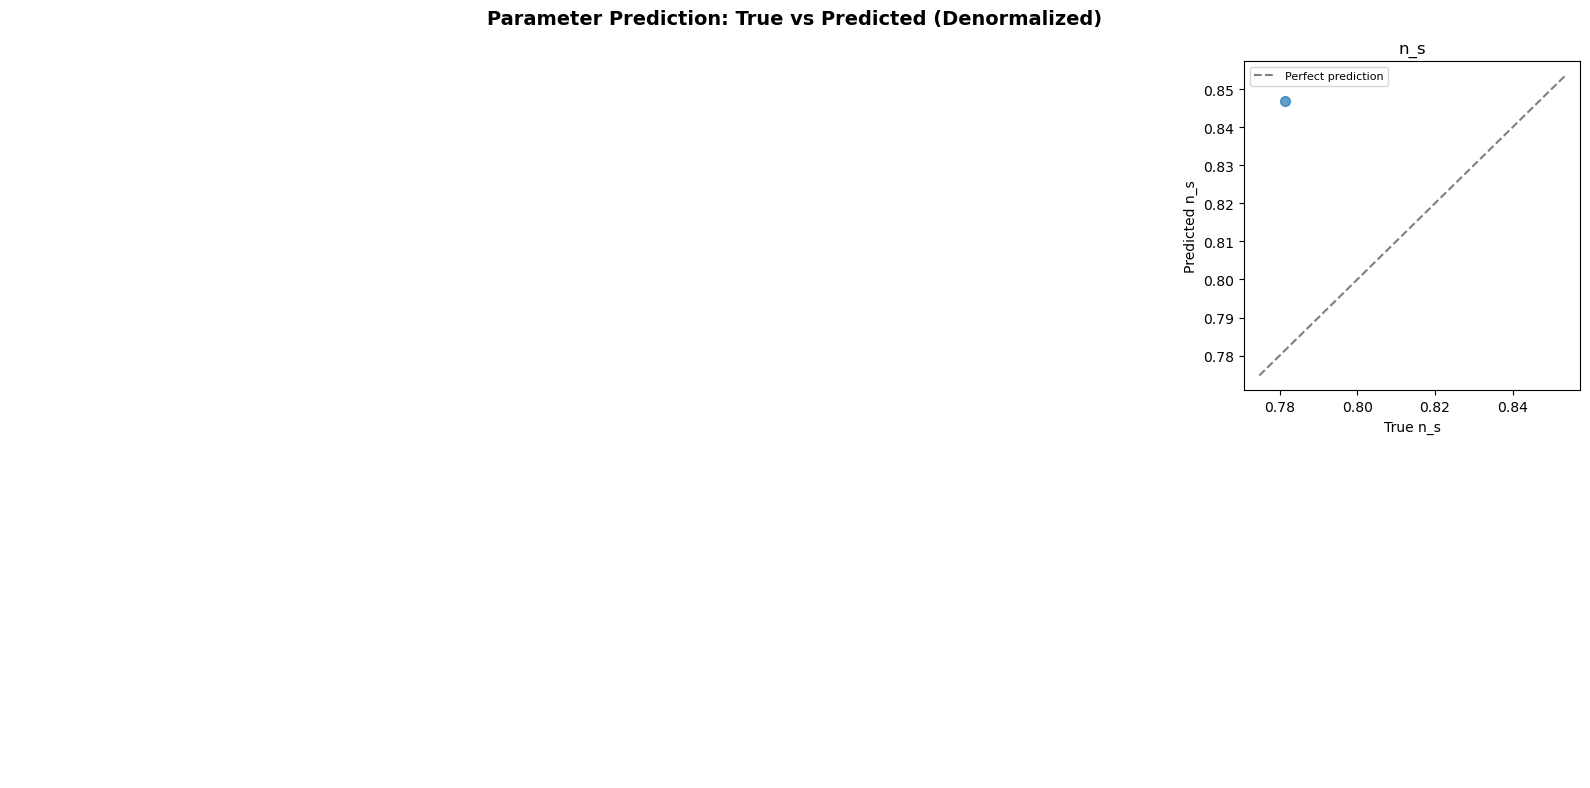

In [8]:
if param_pred_normalized is not None:
    # Scatter plots: predicted vs true for key cosmological parameters
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    key_params = ['Omega_m', 'Omega_b', 'h', 'n_s', 'sigma_8', 'A_SN1', 'A_AGN1', 'A_SN2']
    
    for i, (ax, name) in enumerate(zip(axes.flat, key_params)):
        # Find the index for this parameter
        try:
            param_idx = param_names.index(name)
        except ValueError:
            ax.axis('off')
            continue
            
        if param_idx >= n_params:
            ax.axis('off')
            continue
            
        true = param_true_np[:, param_idx]
        pred = param_pred_np[:, param_idx]
        
        ax.scatter(true, pred, alpha=0.7, s=50)
        
        # Add diagonal line
        lims = [min(true.min(), pred.min()), max(true.max(), pred.max())]
        margin = (lims[1] - lims[0]) * 0.1
        ax.plot([lims[0]-margin, lims[1]+margin], [lims[0]-margin, lims[1]+margin], 
                'k--', alpha=0.5, label='Perfect prediction')
        
        # Correlation (only valid with >1 sample)
        if len(true) > 1 and true.std() > 1e-6 and pred.std() > 1e-6:
            corr = pearsonr(true, pred)[0]
            ax.set_title(f'{name} (r={corr:.3f})')
        else:
            ax.set_title(f'{name}')
            
        ax.set_xlabel(f'True {name}')
        ax.set_ylabel(f'Predicted {name}')
        ax.legend(fontsize=8)
    
    plt.suptitle('Parameter Prediction: True vs Predicted (Denormalized)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No parameter predictions available")

## 5. Test with Different Parameter Values

Let's test with a range of known parameter values to see how well the model predicts them.

In [12]:
# Test with multiple samples from the test set for better statistics
# Randomly select N_SAMPLES from different simulations
N_SAMPLES = 100

# Get the underlying dataset and sample randomly from it
test_dataset = datamodule.test_dataloader().dataset

total_samples = len(test_dataset)
print(f"Total test samples: {total_samples}")

# Random indices for diversity across different simulations
np.random.seed(42)
indices = np.random.choice(total_samples, size=min(N_SAMPLES, total_samples), replace=False)
print(f"Selected {len(indices)} random samples from across the test set")

# Load selected samples
all_conds, all_large_scale, all_targets, all_params = [], [], [], []
for idx in indices:
    cond_i, ls_i, tgt_i, par_i = test_dataset[idx]
    all_conds.append(cond_i.unsqueeze(0))
    all_large_scale.append(ls_i.unsqueeze(0))
    all_targets.append(tgt_i.unsqueeze(0))
    all_params.append(par_i.unsqueeze(0))

# Concatenate
cond_all = torch.cat(all_conds, dim=0).to(DEVICE)
large_scale_all = torch.cat(all_large_scale, dim=0).to(DEVICE)
target_all = torch.cat(all_targets, dim=0).to(DEVICE)
param_all = torch.cat(all_params, dim=0).to(DEVICE)

# Slice params if needed
if param_all.shape[1] > n_params:
    param_all = param_all[:, :n_params]

full_cond_all = torch.cat([cond_all, large_scale_all], dim=1)

# Check parameter diversity
unique_omega_m = len(np.unique(param_all[:, 0].cpu().numpy().round(3)))
print(f"Loaded {cond_all.shape[0]} test samples with ~{unique_omega_m} unique Ω_m values")

Total test samples: 42720
Selected 100 random samples from across the test set
Loaded 100 test samples with ~52 unique Ω_m values


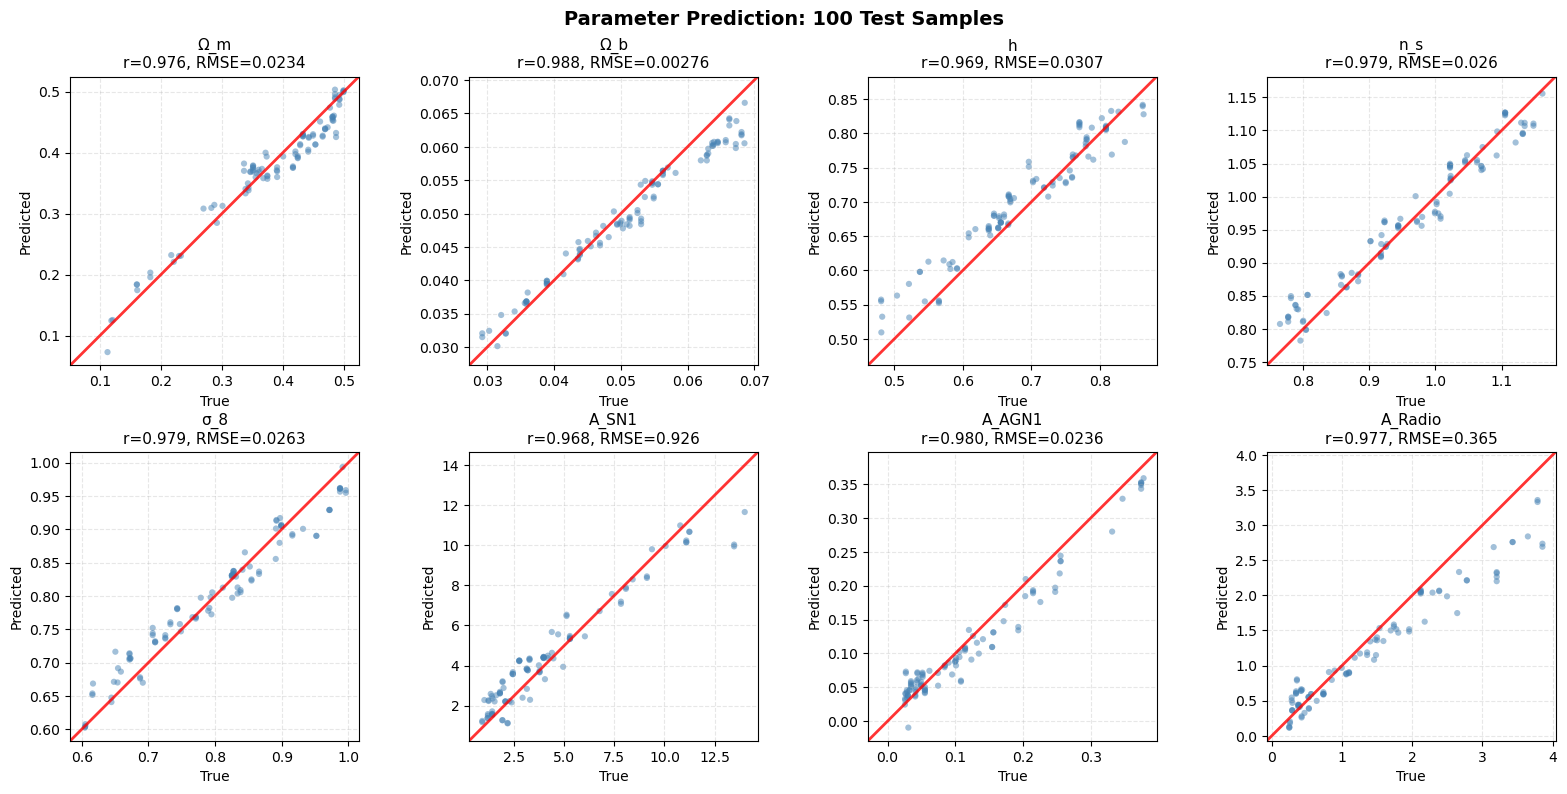


SUMMARY: Parameter Prediction Quality
Parameter                           Correlation  RMSE            MAE            
--------------------------------------------------------------------------------
Omega_b                             0.9879       0.002765        0.002119       
UVBH0Deltaz                         0.9869       0.338907        0.273370       
RadioFeedbackReiorientationFactor   0.9867       2.363311        1.725483       
MaxSfrTimescale                     0.9832       0.332398        0.265658       
SNIa_Rate_Norm                      0.9822       0.000076        0.000064       
BlackHoleRadiativeEfficiency        0.9809       0.053047        0.044617       
SofteningComovingType01             0.9807       0.228153        0.185819       
VariableWindVelFactor               0.9801       0.801237        0.661604       
IMFslope                            0.9800       0.053163        0.042421       
A_AGN1                              0.9797       0.023567        0.018

In [13]:
# Run prediction on all samples
with torch.no_grad():
    n_samples = cond_all.shape[0]
    t = torch.ones(n_samples, device=DEVICE) * 0.5
    gamma_t = clean_vdm.gamma(t)
    alpha_t = torch.sqrt(torch.sigmoid(-gamma_t))[:, None, None, None]
    sigma_t = torch.sqrt(torch.sigmoid(gamma_t))[:, None, None, None]
    
    noise = torch.randn_like(target_all)
    z_t = alpha_t * target_all + sigma_t * noise
    
    result = clean_vdm.score_model(z_t, g_t=gamma_t, conditioning=full_cond_all, param_conditioning=param_all)
    
    if isinstance(result, tuple):
        _, param_pred_all_norm = result
    else:
        param_pred_all_norm = None

if param_pred_all_norm is not None:
    # Denormalize predictions
    param_pred_all = param_pred_all_norm * (param_max_dev - param_min_dev) + param_min_dev
    param_pred_all_np = param_pred_all.cpu().numpy()
    param_true_all_np = param_all.cpu().numpy()
    
    # Plot key cosmological parameters with IMPROVED visualization
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    # Use actual CSV column names that exist
    key_params_csv = ['Omega0', 'OmegaBaryon', 'HubbleParam', 'n_s', 'sigma8', 
                      'WindEnergyIn1e51erg', 'BlackHoleFeedbackFactor', 'RadioFeedbackFactor']
    key_params_display = ['Ω_m', 'Ω_b', 'h', 'n_s', 'σ_8', 'A_SN1', 'A_AGN1', 'A_Radio']
    
    for ax, csv_name, display_name in zip(axes.flat, key_params_csv, key_params_display):
        try:
            param_idx = param_names.index(csv_name)
        except ValueError:
            ax.axis('off')
            continue
            
        if param_idx >= n_params:
            ax.axis('off')
            continue
            
        true = param_true_all_np[:, param_idx]
        pred = param_pred_all_np[:, param_idx]
        
        # Scatter plot with better visibility
        ax.scatter(true, pred, alpha=0.5, s=20, c='steelblue', edgecolors='none')
        
        # Diagonal line (perfect prediction)
        all_vals = np.concatenate([true, pred])
        vmin, vmax = all_vals.min(), all_vals.max()
        margin = (vmax - vmin) * 0.05
        ax.plot([vmin-margin, vmax+margin], [vmin-margin, vmax+margin], 
                'r-', lw=2, alpha=0.8, label='Perfect')
        
        # Set equal aspect and limits
        ax.set_xlim(vmin - margin, vmax + margin)
        ax.set_ylim(vmin - margin, vmax + margin)
        ax.set_aspect('equal', adjustable='box')
        
        # Stats
        if true.std() > 1e-8 and pred.std() > 1e-8:
            corr = pearsonr(true, pred)[0]
        else:
            corr = np.nan
        rmse = np.sqrt(np.mean((true - pred)**2))
        
        ax.set_xlabel(f'True', fontsize=10)
        ax.set_ylabel(f'Predicted', fontsize=10)
        ax.set_title(f'{display_name}\nr={corr:.3f}, RMSE={rmse:.3g}', fontsize=11)
        ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.suptitle(f'Parameter Prediction: {n_samples} Test Samples', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Summary table with display names
    print("\n" + "="*80)
    print("SUMMARY: Parameter Prediction Quality")
    print("="*80)
    print(f"{'Parameter':<35} {'Correlation':<12} {'RMSE':<15} {'MAE':<15}")
    print("-"*80)
    
    # Sort by correlation to highlight best/worst
    results = []
    for i, name in enumerate(param_names[:n_params]):
        true = param_true_all_np[:, i]
        pred = param_pred_all_np[:, i]
        if true.std() > 1e-8 and pred.std() > 1e-8:
            corr = pearsonr(true, pred)[0]
        else:
            corr = np.nan
        rmse = np.sqrt(np.mean((true - pred)**2))
        mae = np.mean(np.abs(true - pred))
        display = PARAM_DISPLAY_NAMES.get(name, name)
        results.append((display, corr, rmse, mae))
    
    # Sort by correlation (highest first)
    results.sort(key=lambda x: -x[1] if not np.isnan(x[1]) else -999)
    
    for display, corr, rmse, mae in results:
        corr_str = f'{corr:.4f}' if not np.isnan(corr) else 'N/A'
        print(f"{display:<35} {corr_str:<12} {rmse:<15.6f} {mae:<15.6f}")
    
    # Overall summary
    valid_corrs = [r[1] for r in results if not np.isnan(r[1])]
    print(f"\n{'='*80}")
    print(f"Mean correlation (valid params): {np.mean(valid_corrs):.4f}")
    print(f"Median correlation: {np.median(valid_corrs):.4f}")
    print(f"Best predicted: {results[0][0]} (r={results[0][1]:.4f})")
    print(f"Worst predicted: {results[-1][0]} (r={results[-1][1]:.4f})")
else:
    print("No parameter predictions available")

## 6. Check FiLM Modulation Sensitivity

How much do the FiLM parameters change when we vary cosmology?

In [43]:
# Extract FiLM parameters for different cosmologies
# This checks how much the network modulation changes with different parameters

from vdm.networks_clean import get_timestep_embedding

def get_film_params_from_unet(unet, clean_vdm, params, device):
    """Extract FiLM gamma and beta for given parameters.
    
    The UNet applies FiLM modulation based on:
    1. Time embedding (gamma_t)
    2. Parameter embedding (params)
    
    These are combined and passed to FiLM layers in each ResNet block.
    """
    with torch.no_grad():
        params = params.to(device)
        batch_size = params.shape[0]
        
        # Get parameter embedding from UNet
        param_emb = unet.param_conditioning_embedding(params)  # (B, embed_dim * 4)
        
        # Get time embedding (use fixed t=0.5)
        t = torch.tensor([0.5] * batch_size, device=device)
        gamma_t = clean_vdm.gamma(t)  # (B,)
        
        # Rescale gamma as done in UNet forward pass
        gamma_t_scaled = (gamma_t - unet.gamma_min) / (unet.gamma_max - unet.gamma_min)
        
        # Time embedding using sinusoidal features
        t_embed = get_timestep_embedding(gamma_t_scaled, unet.embedding_dim)  # (B, embed_dim)
        t_cond = unet.embed_t_conditioning(t_embed)  # (B, 4 * embed_dim)
        
        # Combine embeddings via fusion layer (with learnable scales)
        combined = torch.cat([
            unet.time_scale * t_cond,
            unet.param_scale * param_emb
        ], dim=-1)
        combined = unet.conditioning_fusion(combined)
        
        # Get FiLM params from first down block's resnet
        # Each down block has a resnet_block with film_layer
        first_block = unet.down_blocks[0]
        if hasattr(first_block, 'resnet_block') and hasattr(first_block.resnet_block, 'film_layer'):
            film_layer = first_block.resnet_block.film_layer
            film_params = film_layer.film_proj(combined)
            
            gamma = film_params[:, :film_params.shape[1]//2] + 1.0  # +1 for identity
            beta = film_params[:, film_params.shape[1]//2:]
            
            return gamma.cpu().numpy(), beta.cpu().numpy()
        else:
            print("FiLM layer not found in expected location")
            return None, None

# Test with two cosmologies: SB35-like vs CV-like
if param_input.shape[0] > 0:
    sb35_params = param_input[0:1].clone()
    cv_params = param_input[0:1].clone()
    
    # Find Omega_m index using the helper function
    omega_m_idx = get_param_index('Omega_m')
    if omega_m_idx is None:
        omega_m_idx = get_param_index('Omega0')  # Try CSV name
    if omega_m_idx is None:
        omega_m_idx = 0  # Fallback
        print("Omega_m/Omega0 not found, using param 0")
    else:
        print(f"Using Omega_m at index {omega_m_idx} ('{param_names[omega_m_idx]}')")
    
    sb35_params[0, omega_m_idx] = 0.25  # Typical SB35 training range
    cv_params[0, omega_m_idx] = 0.30    # CV cosmology
    
    gamma_sb35, beta_sb35 = get_film_params_from_unet(unet, clean_vdm, sb35_params, DEVICE)
    gamma_cv, beta_cv = get_film_params_from_unet(unet, clean_vdm, cv_params, DEVICE)
    
    if gamma_sb35 is not None:
        print("="*60)
        print("FiLM MODULATION SENSITIVITY")
        print("="*60)
        print(f"\nSB35 cosmology (Omega_m=0.25):")
        print(f"  gamma: mean={gamma_sb35.mean():.6f}, std={gamma_sb35.std():.6f}")
        print(f"  beta:  mean={beta_sb35.mean():.6f}, std={beta_sb35.std():.6f}")
        
        print(f"\nCV cosmology (Omega_m=0.30):")
        print(f"  gamma: mean={gamma_cv.mean():.6f}, std={gamma_cv.std():.6f}")
        print(f"  beta:  mean={beta_cv.mean():.6f}, std={beta_cv.std():.6f}")
        
        print(f"\nDifference (CV - SB35):")
        print(f"  delta_gamma: mean={np.mean(gamma_cv - gamma_sb35):.6f}")
        print(f"  delta_beta:  mean={np.mean(beta_cv - beta_sb35):.6f}")
        print(f"  |delta_gamma|: {np.mean(np.abs(gamma_cv - gamma_sb35)):.6f}")
        print(f"  |delta_beta|:  {np.mean(np.abs(beta_cv - beta_sb35)):.6f}")
        
        # Relative change
        rel_gamma_change = np.mean(np.abs(gamma_cv - gamma_sb35)) / np.mean(np.abs(gamma_sb35)) * 100
        print(f"\nRelative gamma change: {rel_gamma_change:.4f}%")
else:
    print("No parameters available for FiLM analysis")

Using Omega_m at index 0 ('Omega0')
FiLM MODULATION SENSITIVITY

SB35 cosmology (Omega_m=0.25):
  gamma: mean=1.029934, std=0.941552
  beta:  mean=0.005486, std=0.222215

CV cosmology (Omega_m=0.30):
  gamma: mean=1.031385, std=0.938320
  beta:  mean=0.005822, std=0.222328

Difference (CV - SB35):
  delta_gamma: mean=0.001451
  delta_beta:  mean=0.000336
  |delta_gamma|: 0.010191
  |delta_beta|:  0.005373

Relative gamma change: 0.8944%


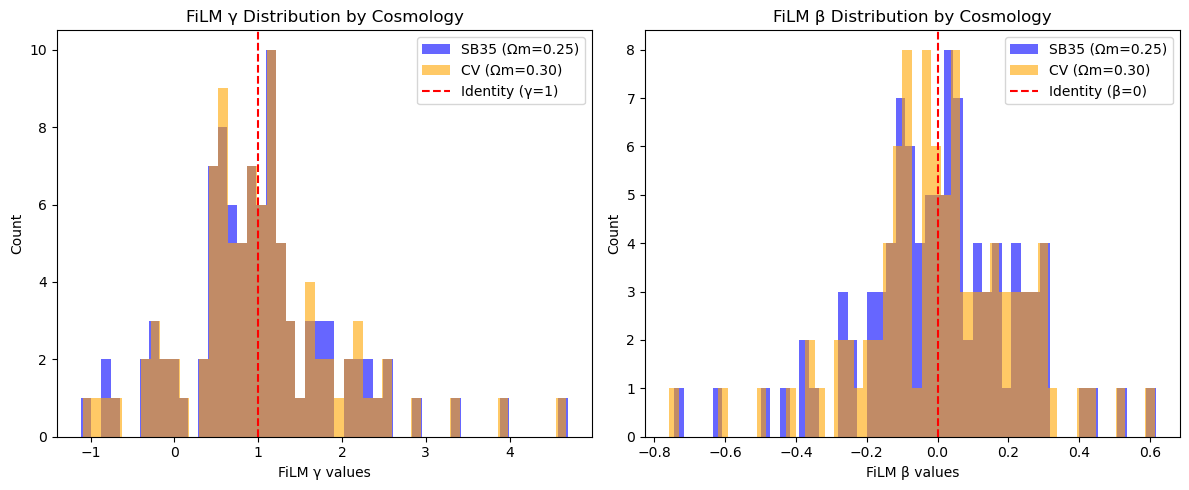


FiLM SENSITIVITY SWEEP


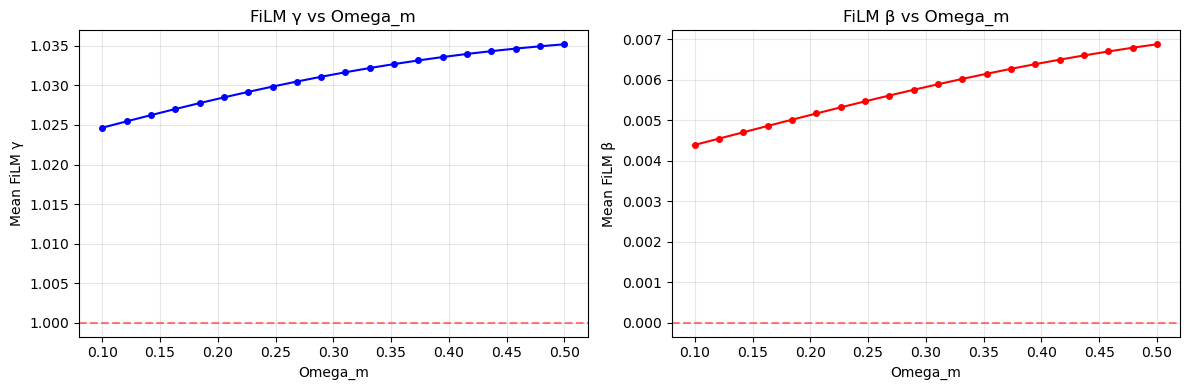

In [41]:
# Visualize FiLM parameter distributions
if gamma_sb35 is not None and gamma_cv is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Gamma distribution
    ax = axes[0]
    ax.hist(gamma_sb35.flatten(), bins=50, alpha=0.6, label='SB35 (Ωm=0.25)', color='blue')
    ax.hist(gamma_cv.flatten(), bins=50, alpha=0.6, label='CV (Ωm=0.30)', color='orange')
    ax.axvline(1.0, color='red', linestyle='--', label='Identity (γ=1)')
    ax.set_xlabel('FiLM γ values')
    ax.set_ylabel('Count')
    ax.set_title('FiLM γ Distribution by Cosmology')
    ax.legend()

    # Beta distribution
    ax = axes[1]
    ax.hist(beta_sb35.flatten(), bins=50, alpha=0.6, label='SB35 (Ωm=0.25)', color='blue')
    ax.hist(beta_cv.flatten(), bins=50, alpha=0.6, label='CV (Ωm=0.30)', color='orange')
    ax.axvline(0.0, color='red', linestyle='--', label='Identity (β=0)')
    ax.set_xlabel('FiLM β values')
    ax.set_ylabel('Count')
    ax.set_title('FiLM β Distribution by Cosmology')
    ax.legend()

    plt.tight_layout()
    plt.show()
    
    # Additional: sweep Omega_m and plot FiLM sensitivity
    print("\n" + "="*60)
    print("FiLM SENSITIVITY SWEEP")
    print("="*60)
    
    omega_m_values = np.linspace(0.1, 0.5, 20)
    gamma_means = []
    beta_means = []
    
    for om in omega_m_values:
        test_params = param_input[0:1].clone()
        try:
            test_params[0, param_names.index('Omega_m')] = om
        except:
            test_params[0, 0] = om
        
        g, b = get_film_params_from_unet(unet, clean_vdm, test_params, DEVICE)
        if g is not None:
            gamma_means.append(g.mean())
            beta_means.append(b.mean())
    
    if gamma_means:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        axes[0].plot(omega_m_values, gamma_means, 'b-o', markersize=4)
        axes[0].set_xlabel('Omega_m')
        axes[0].set_ylabel('Mean FiLM γ')
        axes[0].set_title('FiLM γ vs Omega_m')
        axes[0].axhline(1.0, color='red', linestyle='--', alpha=0.5)
        axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(omega_m_values, beta_means, 'r-o', markersize=4)
        axes[1].set_xlabel('Omega_m')
        axes[1].set_ylabel('Mean FiLM β')
        axes[1].set_title('FiLM β vs Omega_m')
        axes[1].axhline(0.0, color='red', linestyle='--', alpha=0.5)
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
else:
    print("FiLM parameters not available for visualization")

## 7. Summary

### Interpreting Results

**Parameter Prediction Quality:**
- **High correlation (r > 0.8)**: The auxiliary task is learning useful representations
- **Low correlation (r < 0.3)**: Either param_prediction_weight is too low, or model isn't learning parameter info

**FiLM Modulation Sensitivity:**
- **Large FiLM changes with cosmology (>1%)**: Model is using conditioning effectively
- **Small FiLM changes (<0.1%)**: Model may be ignoring parameter conditioning
- **Gamma ≈ 1, Beta ≈ 0**: FiLM is near-identity (not modulating)

### If Results Are Poor

1. **Increase `param_prediction_weight`** in config (e.g., 0.1 instead of 0.01)
2. **Use stronger FiLM init**: `film_init_strategy = 'kaiming'` or `'separate'`
3. **Check if model was trained with param prediction**: Look for `use_param_prediction = True` in config
4. **Train longer**: Auxiliary tasks often need more epochs to converge

### Key Code Reference

The parameter predictor in `UNetVDM` predicts normalized [0,1] parameters from bottleneck features:
```python
# In networks_clean.py
self.param_predictor = nn.Sequential(
    nn.AdaptiveAvgPool2d(1),  # Global average pooling
    nn.Flatten(),
    nn.Linear(mid_ch_out, 256),
    ...
    nn.Linear(128, n_params)  # Outputs normalized params
)
```